In [1]:
import numpy as np
from numpy import ndarray, int64
import torch

Firstly, we import the data from the data folder. For the task 1 we only want the first question, so we only take the labels of the first question. 

In [2]:
import os
from pathlib import Path
from galaxyzoo.data import load_data
import pandas

img_path = Path("data/images")
labels_path = Path("data/labels.csv")

image_paths, labels_reg = load_data(img_path, labels_path, task="task2")

## Preprocessing
Firstly, we will split the data into train, validation and test sets. 

In [3]:
from sklearn.model_selection import train_test_split

train_images, temp_images, train_labels, temp_labels = train_test_split(
    image_paths,
    labels_reg,
    test_size=0.3,
    random_state=42
)

val_images, test_images, val_labels, test_labels = train_test_split(
    temp_images,
    temp_labels,
    test_size=0.5,
    random_state=42
)

print(f'Training size: {len(train_labels)} ({len(train_labels)/len(labels_reg)*100:.0f}%)')
print(f'Validation size: {len(val_labels)} ({len(val_labels)/len(labels_reg)*100:.0f}%)')
print(f'Test size: {len(test_labels)} ({len(test_labels)/len(labels_reg)*100:.0f}%)')

Training size: 43104 (70%)
Validation size: 9237 (15%)
Test size: 9237 (15%)


Next, we have to create a dataset for each set. We will use a different transformation for the training set, to increase the performance. 

In [4]:
from torchvision import transforms
from galaxyzoo.data import GalaxiesDataset
from torch.utils.data import DataLoader
import torch

dim_pixels = 96

# Compute per-channel mean and std on the training set (needed for Normalize)
stats_transform = transforms.Compose([
    transforms.CenterCrop(220),
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.ToTensor(),
])
stats_dataset = GalaxiesDataset(train_images, train_labels, transform=stats_transform, task="regression")
stats_loader = DataLoader(stats_dataset, batch_size=256, shuffle=False)

mean = torch.zeros(3)
std = torch.zeros(3)
for imgs, _ in stats_loader:
    mean += imgs.mean(dim=[0, 2, 3])
    std += imgs.std(dim=[0, 2, 3])
mean /= len(stats_loader)
std /= len(stats_loader)

print(f"Mean: {mean.tolist()}")
print(f"Std:  {std.tolist()}")

Mean: [0.09532294422388077, 0.08262123167514801, 0.06465335190296173]
Std:  [0.13917230069637299, 0.11667003482580185, 0.10086549073457718]


In [5]:
train_transform = transforms.Compose([
    transforms.CenterCrop(220),
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

validation_test_transform = transforms.Compose([
    transforms.CenterCrop(220),
    transforms.Resize((dim_pixels, dim_pixels)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist()),
])

train_dataset = GalaxiesDataset(train_images, train_labels,
                                transform=train_transform, task="regression")
validation_dataset = GalaxiesDataset(val_images, val_labels,
                                     transform=validation_test_transform, task="regression")
test_dataset = GalaxiesDataset(test_images, test_labels,
                               transform=validation_test_transform, task="regression")

We plot the counts of every answer and also they weighted answer to validate the weights used. 

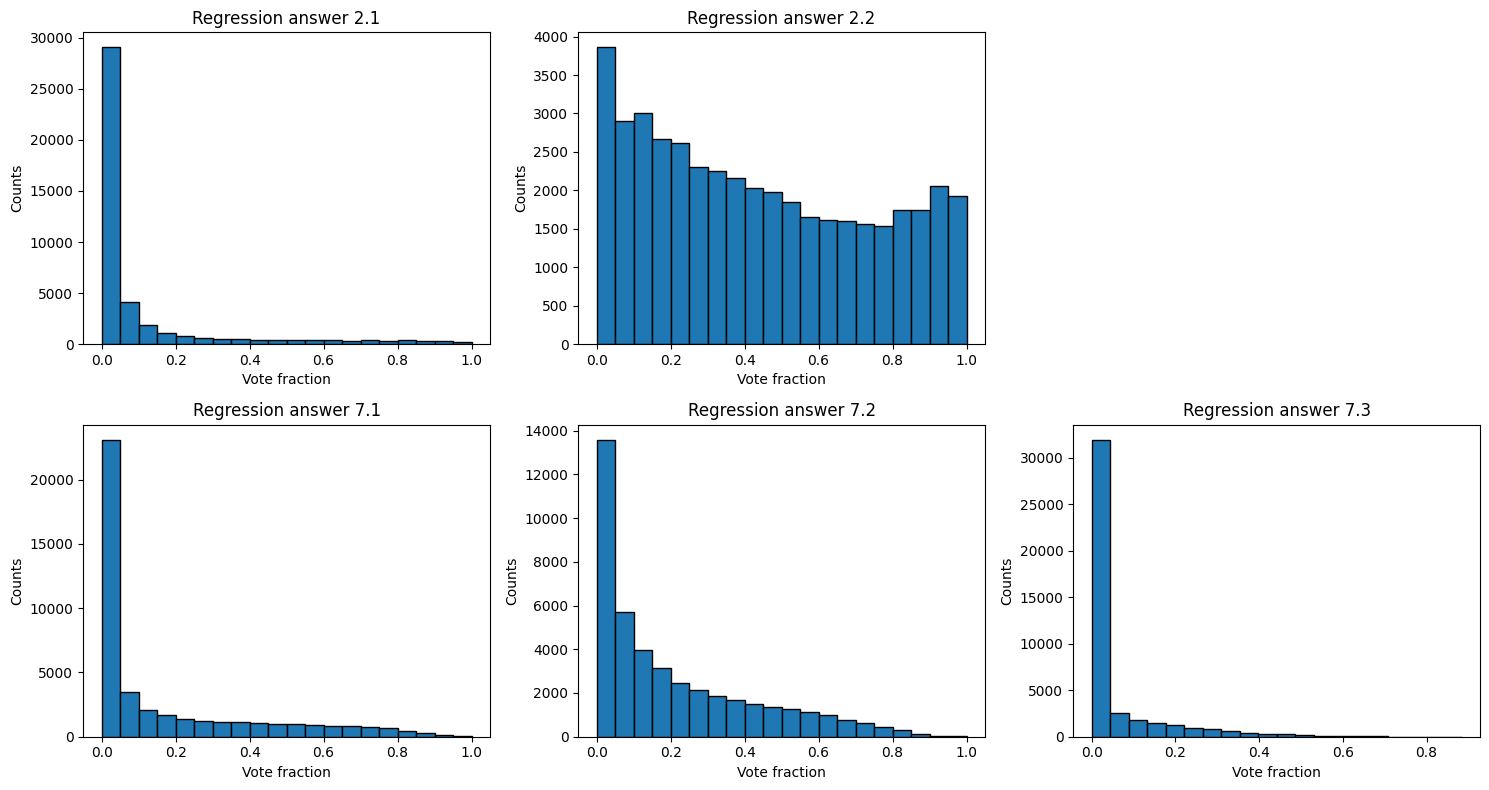

In [6]:
import matplotlib.pyplot as plt

labels_tensor = torch.tensor(train_labels)
bins = 20

# Plot the figure
titles = ["2.1", "2.2", "7.1", "7.2", "7.3"]
n_cols = 3
n_rows = -(-len(titles) // n_cols)  # ceiling division
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axs = axs.flatten()

for n in range(2): # Q2
    axs[n].hist(labels_tensor[:,n], edgecolor='k', bins=bins)
    axs[n].set_xlabel("Vote fraction")
    axs[n].set_ylabel("Counts")
    axs[n].set_title(f"Regression answer {titles[n]}")

for n in range(2,5): # Q7
    axs[n+1].hist(labels_tensor[:,n], edgecolor='k', bins=bins)
    axs[n+1].set_xlabel("Vote fraction")
    axs[n+1].set_ylabel("Counts")
    axs[n+1].set_title(f"Regression answer {titles[n]}")

fig.delaxes(axs[2])
fig.tight_layout()

Next, we will transform the dataset to dataloader of training, validation and test data. 

In [7]:
from torch.utils.data import DataLoader

batch_size=64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Training and fitting
After the preprocessing, we just need to specify the parameters of the model and fit the data. 

In [8]:
from torch import nn
from torch.optim import AdamW
from galaxyzoo.cnn import CNN
from galaxyzoo.training_utils import fit
from torch.optim.lr_scheduler import ReduceLROnPlateau

in_channels = 3     # RGB
out_channels = 5    # 1 channel per answer (5 answers)

cnn_model = CNN(
    in_channels=in_channels,
    out_channels=out_channels,
    input_shape=(dim_pixels, dim_pixels),
    hidden_channels=16,
    final_hidden_channels=64,
    activation="relu",
    task="regression"
)

cnn_optimizer = AdamW(cnn_model.parameters(), lr=5e-4, weight_decay=1e-4)
loss_function = nn.MSELoss()
epochs = 10

scheduler = ReduceLROnPlateau(
    cnn_optimizer,
    mode='min',
    factor=0.5,
    patience=2,
)

train_losses, val_losses, _, _ = fit(
    epochs=epochs,
    loss_function=loss_function,
    model=cnn_model,
    optimizer=cnn_optimizer,
    train_loader=train_loader,
    validation_loader=validation_loader,
    scheduler=scheduler,
    include_accuracy=False, # not needed for regression
)

-----------------------------------------
| Epoch 1                               |
| Train loss: 0.03019232326670818       |
| Validation loss: 0.024379409053202333 |
| Learning rate: 5.00e-04               |
-----------------------------------------
----------------------------------------
| Epoch 2                              |
| Train loss: 0.01899501014893283      |
| Validation loss: 0.01669286975059016 |
| Learning rate: 5.00e-04              |
----------------------------------------
----------------------------------------
| Epoch 3                              |
| Train loss: 0.016231491457040833     |
| Validation loss: 0.01624631782800987 |
| Learning rate: 5.00e-04              |
----------------------------------------
----------------------------------------
| Epoch 4                              |
| Train loss: 0.014805478078398842     |
| Validation loss: 0.02308549867493325 |
| Learning rate: 5.00e-04              |
----------------------------------------
----------

It is more useful to see the loss and the accuracy in a plot. 

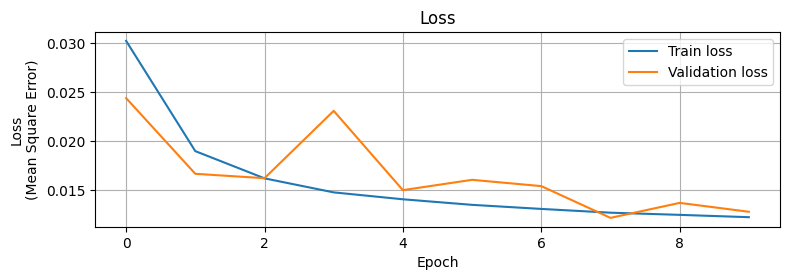

In [9]:
# Plot the figure
fig = plt.figure()
fig.set_figheight(5)
fig.set_figwidth(8)

ax1 = plt.subplot(2,1,1)
ax1.plot(train_losses, label="Train loss")
ax1.plot(val_losses, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss\n(Mean Square Error)")
ax1.set_title("Loss")
ax1.legend()
ax1.grid()

plt.tight_layout()

## Evaluation
Finally, we will evaluate the model with the test data. We will compute the confusion matrix and the ROC curves. 

In [10]:
labels_test = []
labels_preds = []

cnn_model.eval()

with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = cnn_model(imgs)
        labels_test.extend(labels.cpu().numpy())
        labels_preds.extend(outputs.cpu().numpy())
    
    labels_test = np.array(labels_test)
    labels_preds = np.array(labels_preds)

In [11]:
from sklearn.metrics import mean_absolute_error

mae = []
for n in range(5):
    mae.append(
        mean_absolute_error(labels_test[:,n],labels_preds[:,n])
    )

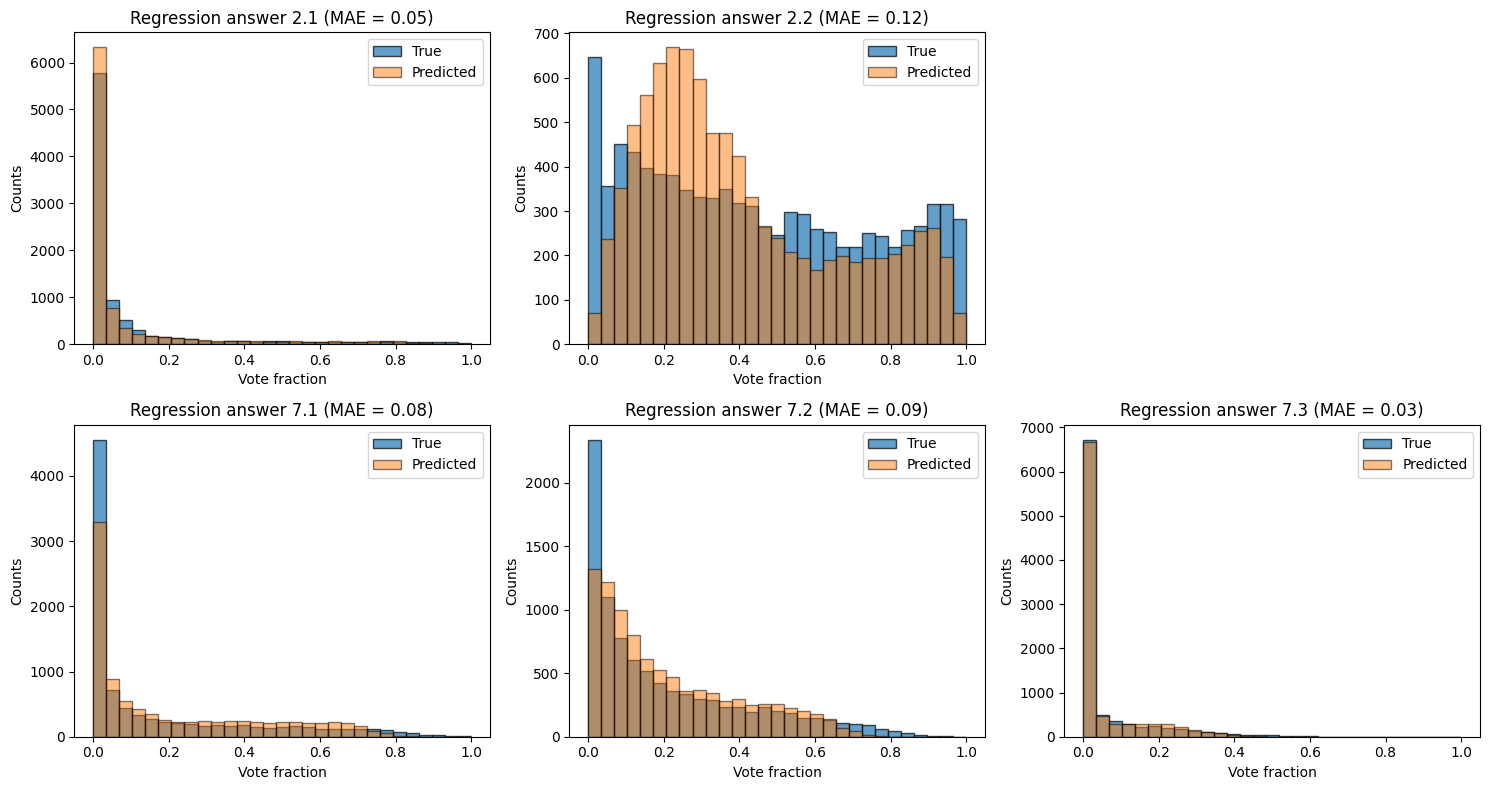

In [12]:
# Plot the figure
bins = np.linspace(0, 1, 30)
titles = ["2.1", "2.2", "7.1", "7.2", "7.3"]
n_cols = 3
n_rows = -(-len(titles) // n_cols)  # ceiling division
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axs = axs.flatten()

for n in range(2): # Q2
    axs[n].hist(labels_test[:,n], edgecolor='k', bins=bins, alpha=0.7, label='True')
    axs[n].hist(labels_preds[:,n], edgecolor='k', bins=bins, alpha=0.5, label='Predicted')
    axs[n].set_xlabel("Vote fraction")
    axs[n].set_ylabel("Counts")
    axs[n].set_title(f"Regression answer {titles[n]} (MAE = {mae[n]:0.2f})")
    axs[n].legend()

for n in range(2,5): # Q7
    axs[n+1].hist(labels_test[:,n], edgecolor='k', bins=bins, alpha=0.7, label='True')
    axs[n+1].hist(labels_preds[:,n], edgecolor='k', bins=bins, alpha=0.5, label='Predicted')
    axs[n+1].set_xlabel("Vote fraction")
    axs[n+1].set_ylabel("Counts")
    axs[n+1].set_title(f"Regression answer {titles[n]} (MAE = {mae[n]:0.2f})")
    axs[n+1].legend()

fig.delaxes(axs[2])
fig.tight_layout()

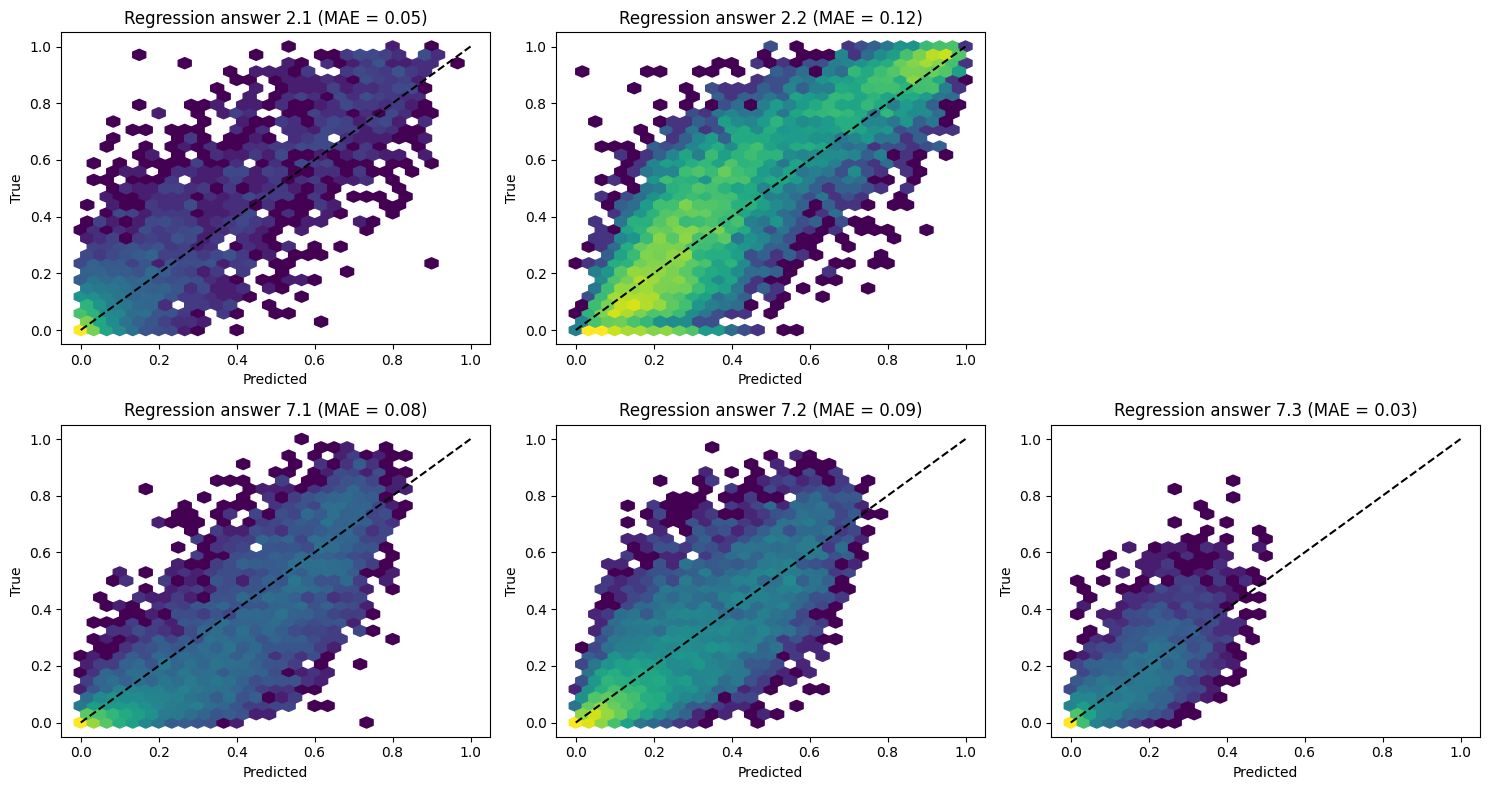

In [13]:
from matplotlib.colors import LogNorm

cmap = plt.cm.viridis
cmap.set_under(cmap(0))

# Plot the figure
titles = ["2.1", "2.2", "7.1", "7.2", "7.3"]
n_cols = 3
n_rows = -(-len(titles) // n_cols)  # ceiling division
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axs = axs.flatten()

for n in range(2): # Q2
    axs[n].hexbin(labels_preds[:,n],labels_test[:,n],
                  gridsize=30, bins='log', extent=(0,1,0,1))
    axs[n].plot([0,1],[0,1], color='k', linestyle='--')
    axs[n].set_xlabel("Predicted")
    axs[n].set_ylabel("True")
    axs[n].set_title(f"Regression answer {titles[n]} (MAE = {mae[n]:0.2f})")

for n in range(2,5): # Q7
    axs[n+1].hexbin(labels_preds[:,n],labels_test[:,n],
                  gridsize=30, bins='log', extent=(0,1,0,1))
    axs[n+1].plot([0,1],[0,1], color='k', linestyle='--')
    axs[n+1].set_xlabel("Predicted")
    axs[n+1].set_ylabel("True")
    axs[n+1].set_title(f"Regression answer {titles[n]} (MAE = {mae[n]:0.2f})")

fig.delaxes(axs[2])
fig.tight_layout()

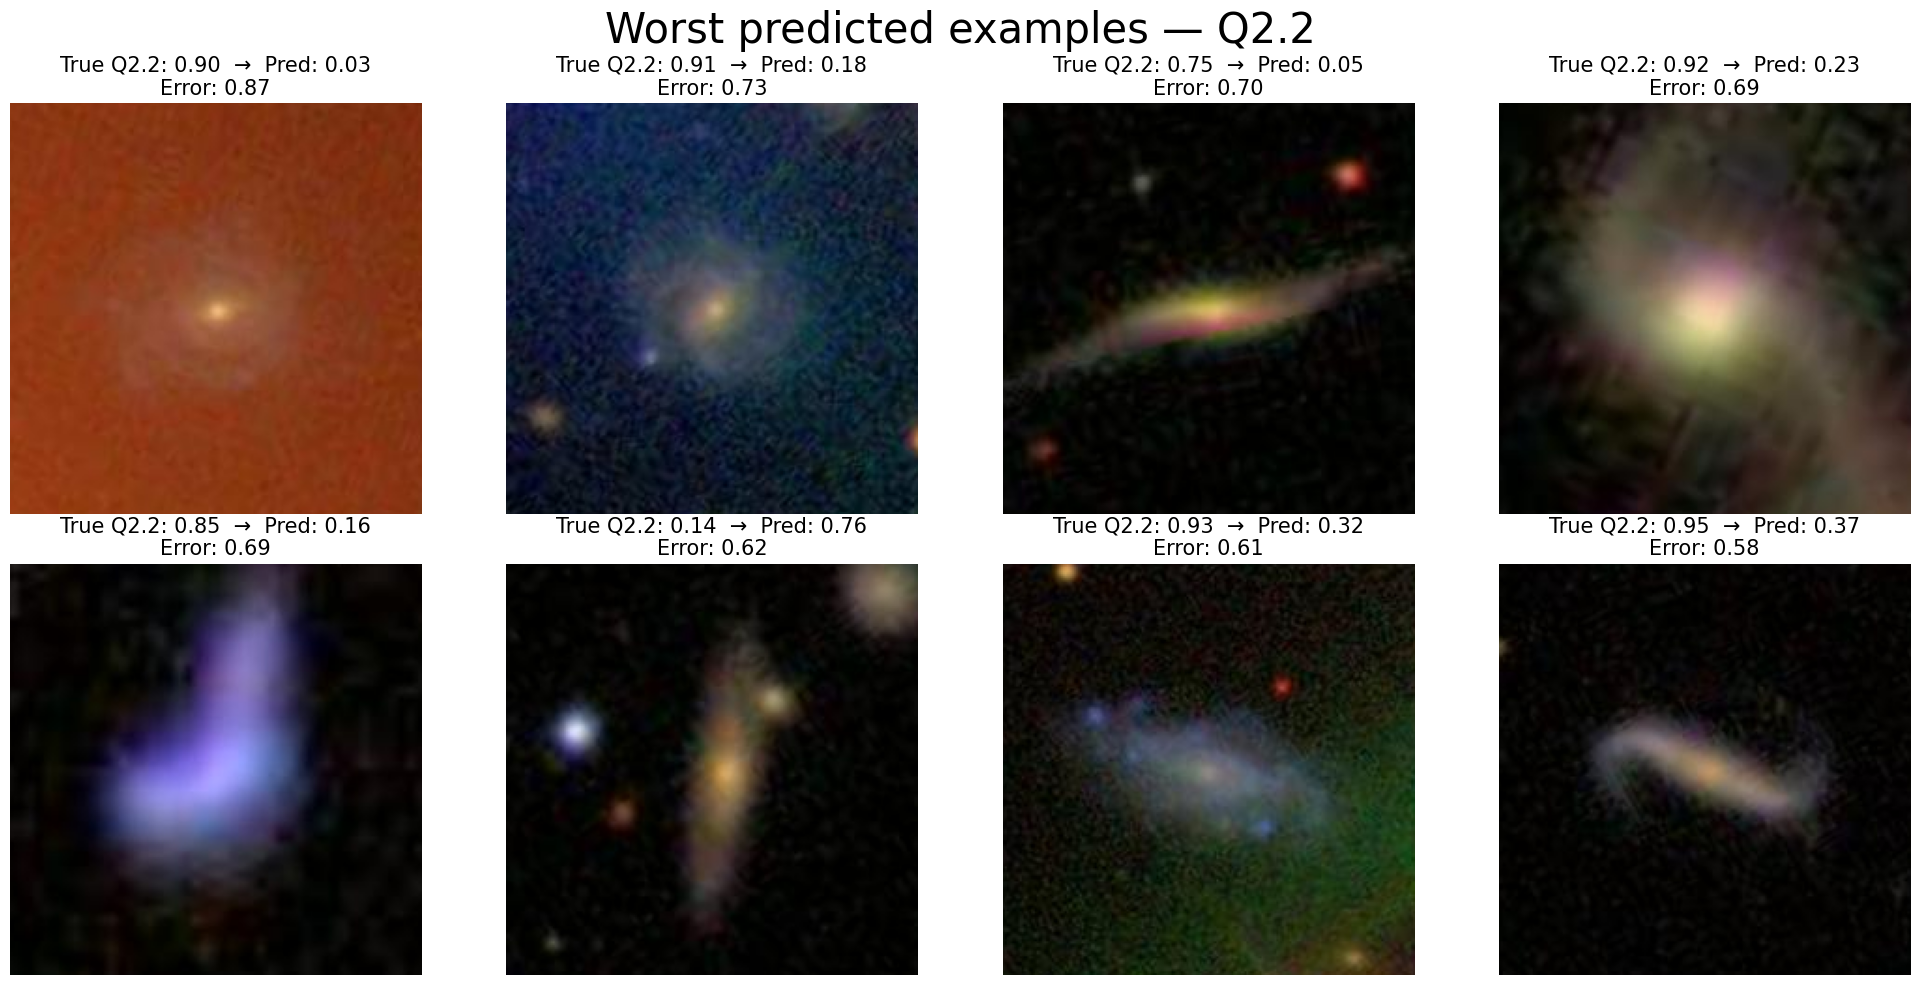

In [17]:
from PIL import Image

n_worst = 8
q_idx = 1  # Q2.2 — disk fraction (highest MAE output)

errors = np.abs(labels_test[:, q_idx] - labels_preds[:, q_idx])
worst_idx = np.argsort(errors)[::-1][:n_worst]

n_cols = 4
n_rows = -(-n_worst // n_cols)
fig, axs = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))
axs = axs.flatten()

for plot_idx, idx in enumerate(worst_idx):
    img_path = test_images[idx]
    img = transforms.CenterCrop(220)(Image.open(img_path).convert("RGB"))
    true_val = labels_test[idx, q_idx]
    pred_val = labels_preds[idx, q_idx]
    axs[plot_idx].imshow(img)
    axs[plot_idx].set_title(
        f"True Q2.2: {true_val:.2f}  →  Pred: {pred_val:.2f}\n"
        f"Error: {abs(true_val - pred_val):.2f}", fontsize=15)
    axs[plot_idx].axis('off')

for i in range(n_worst, len(axs)):
    axs[i].axis('off')

plt.suptitle("Worst predicted examples — Q2.2", fontsize=30)
plt.tight_layout()
plt.show()